# SIH26127 — City-Wide ANPR Prototype (Edge-Tier CV Model)

Pipeline: **YOLOv8 (plate finder, plate-only)** → **OpenCV straightener** → **EasyOCR reader**

This covers the three edge-tier steps from your architecture doc. Trajectory tracking, Kafka ingestion, and the traffic dashboard are separate services outside this notebook.

**Before running:** Kaggle → Notebook Settings → Accelerator → GPU (P100/T4). Attach the `andrewmvd/car-plate-detection`
dataset via **Add Data** — that's the only dataset required end-to-end; the demo in Step 8 reuses its own
validation images as a simulated camera feed, so no separate video upload is needed. Step 7 (OCR text
evaluation) optionally uses a second Kaggle dataset if you attach one.

**Note on the mount path:** on this dataset the real path is nested under `/kaggle/input/datasets/andrewmvd/car-plate-detection/`
(not the shorter `/kaggle/input/car-plate-detection/` some Kaggle datasets use). Step 1 is already set to this verified
path — if you ever re-attach the data and things don't match, run `!find /kaggle/input -maxdepth 4` in a fresh cell to check.

## Step 0 — Setup

In [1]:
!pip install -q ultralytics easyocr

import os, glob, json, random, shutil, time, re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — turn it on in Notebook Settings > Accelerator before continuing.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.7 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


## Step 1 — Dataset: build a plate-only YOLO dataset

`andrewmvd/car-plate-detection` ships Pascal-VOC XML annotations. There is only one object type in this
dataset (the plate region) so we collapse it to a single class: `plate`, class id `0`.

In [2]:
DATASET_DIR = Path("/kaggle/input/datasets/andrewmvd/car-plate-detection")
assert DATASET_DIR.exists(), "Attach the 'andrewmvd/car-plate-detection' dataset via Add Data, then re-run this cell. If this still fails, run `!find /kaggle/input -maxdepth 4` to check the real mount path."

img_dir = DATASET_DIR / "images"
ann_dir = DATASET_DIR / "annotations"

import xml.etree.ElementTree as ET

def parse_voc(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    boxes = []
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)
        boxes.append((xmin, ymin, xmax, ymax))
    return w, h, boxes

out_root = Path("/kaggle/working/plate_yolo")
for split in ["train", "val"]:
    (out_root / "images" / split).mkdir(parents=True, exist_ok=True)
    (out_root / "labels" / split).mkdir(parents=True, exist_ok=True)

xml_files = sorted(ann_dir.glob("*.xml"))
random.seed(42)
random.shuffle(xml_files)
n_val = max(1, int(0.15 * len(xml_files)))
val_set = set(f.stem for f in xml_files[:n_val])

skipped = 0
for xml_path in xml_files:
    stem = xml_path.stem
    img_path = img_dir / f"{stem}.png"
    if not img_path.exists():
        img_path = img_dir / f"{stem}.jpg"
    if not img_path.exists():
        skipped += 1
        continue
    w, h, boxes = parse_voc(xml_path)
    split = "val" if stem in val_set else "train"
    shutil.copy(img_path, out_root / "images" / split / img_path.name)
    lines = []
    for (xmin, ymin, xmax, ymax) in boxes:
        cx = ((xmin + xmax) / 2) / w
        cy = ((ymin + ymax) / 2) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h
        lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    (out_root / "labels" / split / f"{stem}.txt").write_text("\n".join(lines))

print(f"Converted {len(xml_files) - skipped} images, skipped {skipped} (missing image file).")

yaml_text = f"""path: {out_root}
train: images/train
val: images/val
names:
  0: plate
"""
(out_root / "data.yaml").write_text(yaml_text)
print(yaml_text)

Converted 433 images, skipped 0 (missing image file).
path: /kaggle/working/plate_yolo
train: images/train
val: images/val
names:
  0: plate



## Step 2 — Fine-tune YOLOv8 (plate-only)

Starting from the nano checkpoint — fastest to fine-tune, and plenty accurate for one simple class on a
dataset this size. ~40 epochs finishes well under 30 minutes on a Kaggle T4.

In [3]:
from ultralytics import YOLO

detector = YOLO("yolov8n.pt")
train_results = detector.train(
    data=str(out_root / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=16,
    patience=10,
    project="/kaggle/working/runs",
    name="plate_detector",
    verbose=True,
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/plate_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fractio

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/40      2.51G      1.518      2.007      1.278          4        640: 100% ━━━━━━━━━━━━ 24/24 6.3it/s 3.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.6it/s 0.4s
                   all         64         71      0.394     0.0644      0.372      0.183

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      2.51G      1.559       1.87      1.296          2        640: 100% ━━━━━━━━━━━━ 24/24 5.9it/s 4.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.5it/s 0.4s
                   all         64         71      0.188      0.268      0.131      0.054

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/40      2.51G       1.47      1.974      1.238          0        640: 100% ━━━━━━━━━━━━ 24/24 6.1it/s 4.0s
                 Class     Images  Instances      Box(P          R

## Step 3 — Evaluate the detector

mAP@0.5, mAP@0.5:0.95, precision, recall — put these on your slide.

In [4]:
best_weights = "/kaggle/working/runs/plate_detector/weights/best.pt"
detector = YOLO(best_weights)
val_metrics = detector.val(data=str(out_root / "data.yaml"))

print(f"mAP@0.5      : {val_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {val_metrics.box.map:.4f}")
print(f"Precision    : {val_metrics.box.mp:.4f}")
print(f"Recall       : {val_metrics.box.mr:.4f}")

Ultralytics 8.4.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4298.7±947.4 MB/s, size: 602.4 KB)
val: Scanning /kaggle/working/plate_yolo/labels/val.cache... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 24.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.4s
                   all         64         71      0.945      0.901       0.93      0.556
Speed: 3.6ms preprocess, 6.1ms inference, 0.1ms loss, 2.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@0.5      : 0.9297
mAP@0.5:0.95 : 0.5556
Precision    : 0.9450
Recall       : 0.9014


## Step 4 — The Straightener (OpenCV, no learned weights)

For each detected plate crop: edge-detect → find the largest contour → take its minimum-area rotated
rectangle → perspective-warp it flat. Falls back to a plain resize if no clean quadrilateral is found,
so a bad frame during tomorrow's demo doesn't crash the loop.

In [5]:
def order_corners(pts):
    pts = pts[np.argsort(pts[:, 1])]
    top, bottom = pts[:2], pts[2:]
    top = top[np.argsort(top[:, 0])]
    bottom = bottom[np.argsort(bottom[:, 0])]
    return np.array([top[0], top[1], bottom[1], bottom[0]], dtype="float32")  # TL, TR, BR, BL

def straighten_plate(crop, out_w=320, out_h=96):
    if crop is None or crop.size == 0:
        return np.zeros((out_h, out_w, 3), dtype=np.uint8)

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 30, 30)
    edges = cv2.Canny(gray, 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return cv2.resize(crop, (out_w, out_h))

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 0.2 * crop.shape[0] * crop.shape[1]:
        return cv2.resize(crop, (out_w, out_h))  # contour too small/unreliable — skip the warp

    rect = cv2.minAreaRect(largest)
    box = cv2.boxPoints(rect)
    src = order_corners(box)
    dst = np.array([[0, 0], [out_w, 0], [out_w, out_h], [0, out_h]], dtype="float32")
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(crop, M, (out_w, out_h))
    return warped

## Step 5 — The Reader (EasyOCR)

One shared `Reader` instance — loading the weights is the slow part, so do it once. The character
allowlist is restricted to what actually appears on a plate, and the output is upper-cased and stripped
of anything that isn't A-Z/0-9 before it counts as a "read".

In [6]:
import easyocr

ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

PLATE_ALLOWLIST = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

def clean_plate_text(raw):
    return re.sub(r"[^A-Za-z0-9]", "", raw).upper()

def read_plate(straightened_crop):
    results = ocr_reader.readtext(straightened_crop, allowlist=PLATE_ALLOWLIST, detail=1)
    if not results:
        return "", 0.0
    results.sort(key=lambda r: r[0][0][0])  # left-to-right, handles multi-segment reads
    text = "".join(clean_plate_text(r[1]) for r in results)
    conf = float(np.mean([r[2] for r in results]))
    return text, conf

## Step 6 — Chain it: detect → straighten → read

One function that takes a raw frame and returns every plate found in it, boxed and read.

In [7]:
def process_frame(frame, detector, conf_thresh=0.4):
    results = detector.predict(frame, conf=conf_thresh, verbose=False)[0]
    plates = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        det_conf = float(box.conf[0])
        crop = frame[max(0, y1):y2, max(0, x1):x2]
        straight = straighten_plate(crop)
        text, ocr_conf = read_plate(straight)
        plates.append({
            "bbox": (x1, y1, x2, y2),
            "detector_conf": det_conf,
            "text": text,
            "ocr_conf": ocr_conf,
        })
    return plates

## Step 7 — Evaluate the OCR against labeled plate text

Two real Kaggle datasets carry ground-truth plate *text* (not just boxes): `ckay16/indian-number-plate-detection`
and `xairete/car-plates-ocr`. Attach whichever one you grab via **Add Data** — Kaggle's own dataset page
doesn't expose its internal file/column layout to me ahead of time, so this first cell just prints what's
actually inside once it's attached. Tell me what it prints and I'll tighten the loader below to match exactly.

If neither attaches cleanly in time, there's a zero-dependency fallback two cells down: hand-type the plate
text for ~15 images you already have from `andrewmvd/car-plate-detection`'s own validation split — still a
real, honestly-reported CER/accuracy number, just on a smaller hand-labeled sample.

In [8]:
OCR_DATASET_DIR = Path("/kaggle/input")
for p in sorted(OCR_DATASET_DIR.glob("*/*"))[:30]:
    print(p)

/kaggle/input/datasets/andrewmvd


In [9]:
def char_error_rate(pred, gt):
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    dp = list(range(len(gt) + 1))
    for i, pc in enumerate(pred, 1):
        prev = dp[0]
        dp[0] = i
        for j, gc in enumerate(gt, 1):
            cur = dp[j]
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + (pc != gc))
            prev = cur
    return dp[len(gt)] / len(gt)

# --- ADJUST to whatever the inspection cell above printed ---
# Example for a CSV with columns like `image` and `plate_text`:
# import pandas as pd
# labels_df = pd.read_csv(OCR_DATASET_DIR / "<dataset_folder>" / "labels.csv")
# test_samples = list(zip(labels_df["image"], labels_df["plate_text"]))

test_samples = []  # fill in once you've seen the real structure printed above

cers, exact_matches = [], []
for img_name, gt_text in test_samples:
    img = cv2.imread(str(OCR_DATASET_DIR / img_name))
    straight = straighten_plate(img)
    pred_text, _ = read_plate(straight)
    gt_clean = clean_plate_text(gt_text)
    cers.append(char_error_rate(pred_text, gt_clean))
    exact_matches.append(pred_text == gt_clean)

if test_samples:
    print(f"Mean CER            : {np.mean(cers):.4f}")
    print(f"Exact-match accuracy: {np.mean(exact_matches):.4f}")
else:
    print("test_samples is empty — fill it in above once you've checked the dataset structure.")

test_samples is empty — fill it in above once you've checked the dataset structure.


### Fallback: hand-labeled mini test set (no extra dataset needed)

Only use this if Step 7's Kaggle datasets don't pan out in time. Look at ~15 validation images from
`andrewmvd/car-plate-detection` (already attached from Step 1) yourself, type the plate text you read
with your own eyes into the dict below, and reuse the same `char_error_rate` function.

In [10]:
hand_labels = {
    # "image_filename.png": "GROUNDTRUTHTEXT",
}

cers, exact_matches = [], []
for fname, gt_text in hand_labels.items():
    img = cv2.imread(str(out_root / "images" / "val" / fname))
    straight = straighten_plate(img)
    pred_text, _ = read_plate(straight)
    gt_clean = clean_plate_text(gt_text)
    cers.append(char_error_rate(pred_text, gt_clean))
    exact_matches.append(pred_text == gt_clean)

if hand_labels:
    print(f"Mean CER            : {np.mean(cers):.4f}")
    print(f"Exact-match accuracy: {np.mean(exact_matches):.4f}")
else:
    print("hand_labels is empty — fill in a few filename -> plate-text pairs above.")

hand_labels is empty — fill in a few filename -> plate-text pairs above.


## Step 8 — Tomorrow's demo: simulated camera feed (Kaggle data only, no video upload)

Rather than sourcing a separate traffic video, this replays the validation images from
`andrewmvd/car-plate-detection` — the dataset you already attached in Step 1 — one at a time with
synthetic timestamps, exactly like an edge node sampling frames from a live camera. Everything here
runs on data you already have on Kaggle; no extra upload required.

Prints the exact message format from your architecture doc: `"I saw plate <text> at Camera #<id> at <timestamp>"`.

I saw plate 27765772255 at Camera #5 at 10:00:00


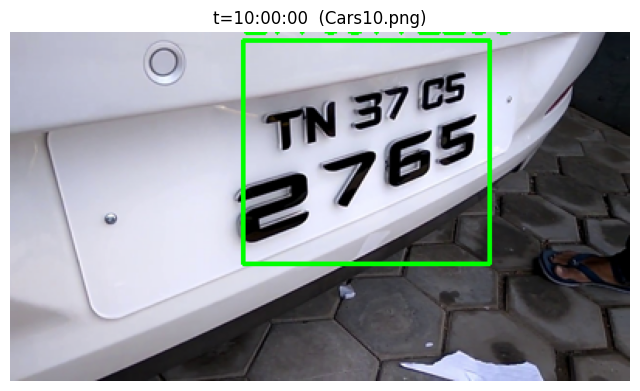

I saw plate HR26BC5S14 at Camera #5 at 10:00:02


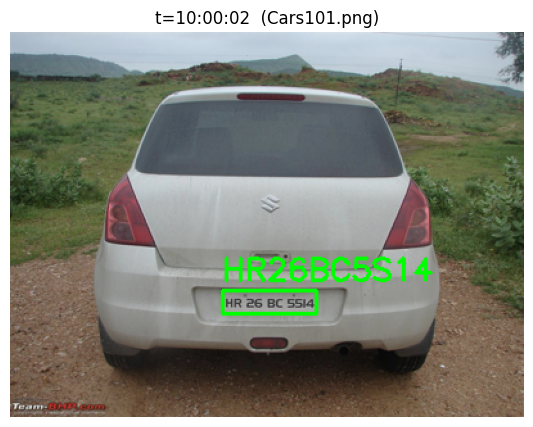

I saw plate MHOTAV8866 at Camera #5 at 10:00:04


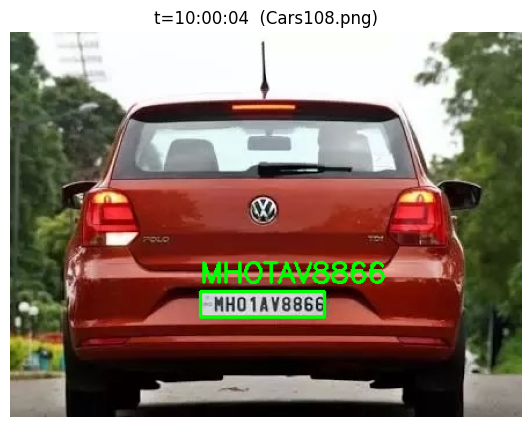

I saw plate FI at Camera #5 at 10:00:06


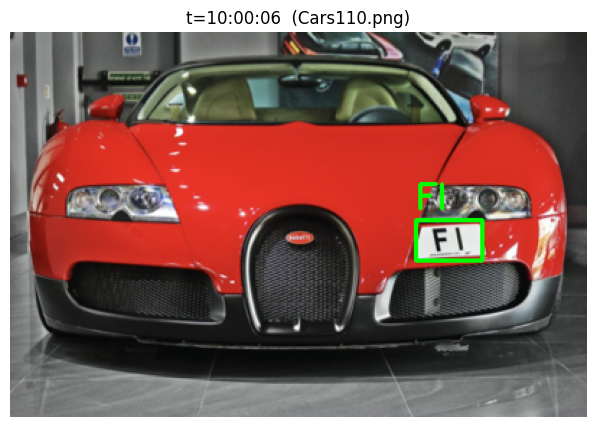

I saw plate OPECLOL at Camera #5 at 10:00:08


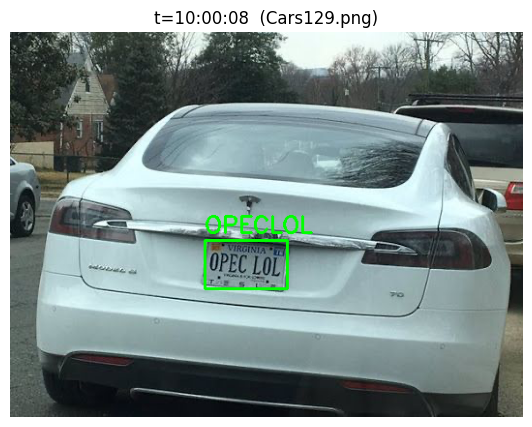

I saw plate 585 at Camera #5 at 10:00:10


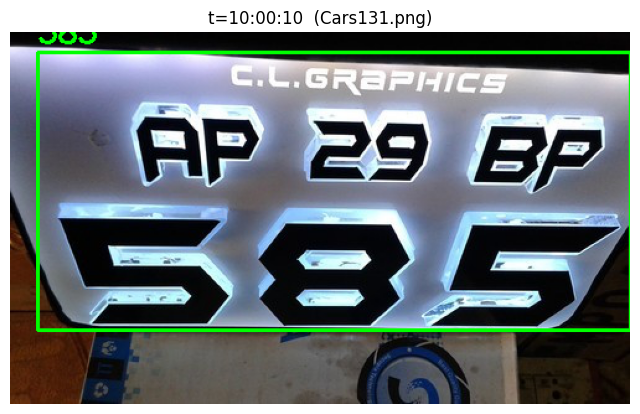

I saw plate FM23RI408 at Camera #5 at 10:00:12
I saw plate M01 at Camera #5 at 10:00:18
I saw plate DL3C205032 at Camera #5 at 10:00:20
I saw plate LSZH59OO at Camera #5 at 10:00:22
I saw plate JHHAD at Camera #5 at 10:00:24
I saw plate CHOIANOOOT at Camera #5 at 10:00:26
I saw plate LUILYJ at Camera #5 at 10:00:28
I saw plate 22525 at Camera #5 at 10:00:32
I saw plate DUAA13 at Camera #5 at 10:00:34
I saw plate IMAU at Camera #5 at 10:00:36
I saw plate DOSIT at Camera #5 at 10:00:38
I saw plate 4CDAF at Camera #5 at 10:00:40
I saw plate PREALSLR at Camera #5 at 10:00:42
I saw plate 21580127 at Camera #5 at 10:00:44
I saw plate TSETCZ8 at Camera #5 at 10:00:46
I saw plate 48YD63LBI at Camera #5 at 10:00:48
I saw plate MH20EE7598 at Camera #5 at 10:00:50
I saw plate FM23RI408 at Camera #5 at 10:00:52
I saw plate IV4U5333 at Camera #5 at 10:00:54
I saw plate DZI7YXR at Camera #5 at 10:00:56
I saw plate 722 at Camera #5 at 10:01:00
I saw plate KA09MA2662 at Camera #5 at 10:01:02
I saw pla

In [11]:
FEED_DIR = out_root / "images" / "val"  # reuse Step 1's val split as a stand-in camera feed
CAMERA_ID = 5
FRAME_INTERVAL_S = 2.0        # pretend each image arrives 2s apart, like sampled camera frames
MAX_FRAMES_TO_DISPLAY = 6     # how many annotated frames to show inline (not every frame)

feed_images = sorted(FEED_DIR.glob("*.*"))
assert feed_images, f"No images found in {FEED_DIR} — did Step 1 run?"

start_epoch = time.mktime(time.strptime("10:00:00", "%H:%M:%S"))
seen_this_run = []
shown = 0

for i, img_path in enumerate(feed_images):
    frame = cv2.imread(str(img_path))
    if frame is None:
        continue
    ts = time.strftime("%H:%M:%S", time.localtime(start_epoch + i * FRAME_INTERVAL_S))
    plates = process_frame(frame, detector)

    vis = frame.copy()
    for p in plates:
        x1, y1, x2, y2 = p["bbox"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, p["text"] or "?", (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        if p["text"]:
            msg = f'I saw plate {p["text"]} at Camera #{CAMERA_ID} at {ts}'
            print(msg)
            seen_this_run.append(msg)

    if shown < MAX_FRAMES_TO_DISPLAY and plates:
        plt.figure(figsize=(8, 5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"t={ts}  ({img_path.name})")
        plt.show()
        shown += 1

print(f"\nTotal plate reads this run: {len(seen_this_run)}")

### Optional: swap in a real video if you get one before tomorrow

If you do get your hands on a short (10–30s) traffic/dashcam clip, upload it as a Kaggle dataset and use
this instead of Step 8's image loop — same `process_frame()`, just fed from `cv2.VideoCapture`.

In [12]:
VIDEO_PATH = "/kaggle/input/<your-video-dataset>/sample.mp4"  # <-- set this if you have a real clip
SAMPLE_EVERY_N_FRAMES = 5  # simulate a lower "edge" sampling rate

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
frame_idx = 0
shown = 0
seen_this_run = []

while True:
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx % SAMPLE_EVERY_N_FRAMES == 0:
        elapsed_s = frame_idx / fps
        ts = time.strftime("%H:%M:%S", time.gmtime(elapsed_s))
        plates = process_frame(frame, detector)

        vis = frame.copy()
        for p in plates:
            x1, y1, x2, y2 = p["bbox"]
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(vis, p["text"] or "?", (x1, max(0, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            if p["text"]:
                msg = f'I saw plate {p["text"]} at Camera #{CAMERA_ID} at {ts}'
                print(msg)
                seen_this_run.append(msg)

        if shown < MAX_FRAMES_TO_DISPLAY and plates:
            plt.figure(figsize=(8, 5))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title(f"t={ts}")
            plt.show()
            shown += 1

    frame_idx += 1

cap.release()
print(f"\nTotal plate reads this run: {len(seen_this_run)}")


Total plate reads this run: 0


## Beyond tomorrow

This notebook is the edge-tier CV model only (finder → straightener → reader). Trajectory tracking, GIS
mapping, Kafka ingestion, and the traffic-analytics dashboard from your architecture doc are separate
services outside this notebook's scope — say if you want help scaffolding any of those next.